# LLM Preference Elicitation with GRUMs — Colors Domain

## 1. Introduction & Context

### What is this notebook about?

This notebook presents the results of applying **Generalized Rank-Utility Models (GRUMs)** to preference elicitation from Large Language Models (LLMs). The domain used here is a set of five colors — **Blue, Red, Green, Purple, Yellow** — chosen as a simple, controlled testbed to validate the methodology before scaling to richer domains (e.g., laptops).

### How does this differ from the reproduction notebook?

The previous notebook `1_reproduction.ipynb` **reproduced** the original GRUM paper's figures. In that setting, agents are real or synthetically sampled personas with features drawn from the dataset itself.

Here, we make a fundamentally different modeling choice:

| Aspect | Reproduction (`1_reproduction.ipynb`) | **This notebook** |
|---|---|---|
| **Agent source** | Personas from the dataset | LLM prompt contexts |
| **Agent features** | Dataset-supplied feature vectors (demographics for Sushi; latent coords for synthetic ds0–2) | PCA of LLM internal representations: Hidden State + PCA (`HS`) or Sentence Transformer + PCA (`ST`) |
| **Preference data** | Synthetic (ds0–2) or real human rankings (Sushi) | LLM pairwise choices (via perplexity scoring) |
| **Goal** | Validate GRUM implementation against paper | Validate GRUM for LLM persona elicitation |

### Experiment Dimensions

We test across three independent axes:

| Dimension | Values |
|---|---|
| **LLM Model** | `Qwen2.5-0.5B` (Pretrained) · `Qwen2.5-0.5B-Instruct` (Instruct) |
| **Agent Embedding** | Hidden State PCA (`HS`) · Sentence Transformer PCA (`ST`) |
| **Elicitation Criterion** | `social` · `personalized` · `random` |

This yields **12 experimental configurations** in total.

### Three Conjectures

1. **Intrinsic alignment**: GRUM's $\delta$ will correlate strongly with BT's $\beta$ — BT captures the *average* preference.
2. **Persona effect**: The interaction matrix $B$ will be non-zero, producing *rank reversals* under different prompt contexts.
3. **Predictive advantage**: GRUM will achieve lower NLL than BT on held-out prompt contexts.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Domain constants ──────────────────────────────────────────────────────────
COLOR_NAMES   = ["blue", "red", "green", "purple", "yellow"]
COLOR_PALETTE = {
    "blue": "#1f77b4", "red": "#d62728", "green": "#2ca02c",
    "purple": "#9467bd", "yellow": "#d6c427"
}
CRITERIA      = ["Social", "Personalized", "Random"]
EMBEDDINGS    = ["HS", "ST"]
MODELS        = ["Pretrained", "Instruct"]

print("Setup complete.")

Setup complete.


## 2. Data Loading

We load all 12 result JSON files from the main experiment run. Each file captures:
- **Metadata**: model, embedding method, elicitation criterion, PCA dimension
- **`history`**: per-training-step snapshots of GRUM parameters ($\delta$, $B$) and BT weights ($\beta$)
- **`timing`**: wall-clock training duration

From each run we extract:
1. The **final-step** GRUM $\delta$ (intrinsic preferences) and $B$ (interaction matrix)
2. The **final-step** BT $\beta$ weights
3. The full **history** (for convergence plots)

In [2]:
RESULTS_DIR = Path("../artifacts/llm/colors/outputs")

def embed_label(method: str) -> str:
    if "hidden_state" in method:
        return "HS"
    if "sentence_transformer" in method:
        return "ST"
    return method

def model_label(model_id: str) -> str:
    return "Instruct" if "Instruct" in model_id else "Pretrained"

raw_results = []

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    with open(fpath) as f:
        data = json.load(f)

    history = data["history"]
    last    = history[max(history.keys(), key=int)]

    delta_grum = np.array(last["grum"]["delta"])
    B          = np.array(last["grum"]["interaction"])
    beta_bt    = np.array(last["bt"]["beta"])
    
    nll_grum_final = last["grum"].get("nll", last.get("nll", float("nan")))
    nll_bt_final   = last["bt"].get("nll", float("nan"))

    # Full history for convergence plots
    steps_sorted    = sorted(history.keys(), key=int)
    delta_hist_grum = np.array([history[s]["grum"]["delta"] for s in steps_sorted])
    beta_hist_bt    = np.array([history[s]["bt"]["beta"]   for s in steps_sorted])
    
    nll_hist_grum   = np.array([history[s]["grum"].get("nll", history[s].get("nll", float("nan"))) for s in steps_sorted])
    nll_hist_bt     = np.array([history[s]["bt"].get("nll", float("nan")) for s in steps_sorted])

    raw_results.append({
        "Model":     model_label(data["model_id"]),
        "Embedding": embed_label(data["embedding_method"]),
        "Criterion": data["criterion"].capitalize(),
        "model_id":  data["model_id"],
        "pca_dim":   data["pca_dim"],
        "steps":     data["steps"],
        "RawEmbedding": data["embedding_method"],
        "Seed":      data["seed"],
        "Domain":    data["domain"],
        "delta_grum":      delta_grum,
        "B":               B,
        "beta_bt":         beta_bt,
        "nll_grum":        nll_grum_final,
        "nll_bt":          nll_bt_final,
        "delta_hist_grum": delta_hist_grum,
        "beta_hist_bt":    beta_hist_bt,
        "nll_hist_grum":   nll_hist_grum,
        "nll_hist_bt":     nll_hist_bt,
        "timing":    data.get("timing", {}),
        "agent_features": data.get("agent_features", {}),
    })

print(f"Loaded {len(raw_results)} runs.")
df_meta = pd.DataFrame([{
    k: v for k, v in r.items()
    if "grum" not in k and "bt" not in k and k != "B" and k != "timing" and k != "agent_features"
} for r in raw_results])
display(df_meta[["Model", "Embedding", "Criterion", "pca_dim", "steps", "RawEmbedding"]])



Loaded 12 runs.


,Model,Embedding,Criterion,pca_dim,steps,RawEmbedding
0,Pretrained,ST,Social,8,500,sentence_transformer_pca
1,Pretrained,HS,Social,8,500,hidden_state_pca
2,Instruct,ST,Social,8,500,sentence_transformer_pca
3,Instruct,HS,Social,8,500,hidden_state_pca
4,Pretrained,ST,Personalized,8,500,sentence_transformer_pca
5,Pretrained,HS,Personalized,8,500,hidden_state_pca
6,Instruct,ST,Personalized,8,500,sentence_transformer_pca
7,Instruct,HS,Personalized,8,500,hidden_state_pca
8,Pretrained,ST,Random,8,500,sentence_transformer_pca
9,Pretrained,HS,Random,8,500,hidden_state_pca


---

## 3. Experiment 1 — Intrinsic Preferences: GRUM δ vs BT β

**Conjecture**: The GRUM's intrinsic parameters $\delta$ will strongly correlate with the BT weights $\beta$. Intuitively, BT treats all prompt-to-prompt variation as random noise and thus estimates the *population average* preference, while GRUM explicitly models that variation via $B$. If the conjecture holds, the $\delta$ vector should be a more granular version of BT — pointing in the same direction but potentially with different magnitudes.

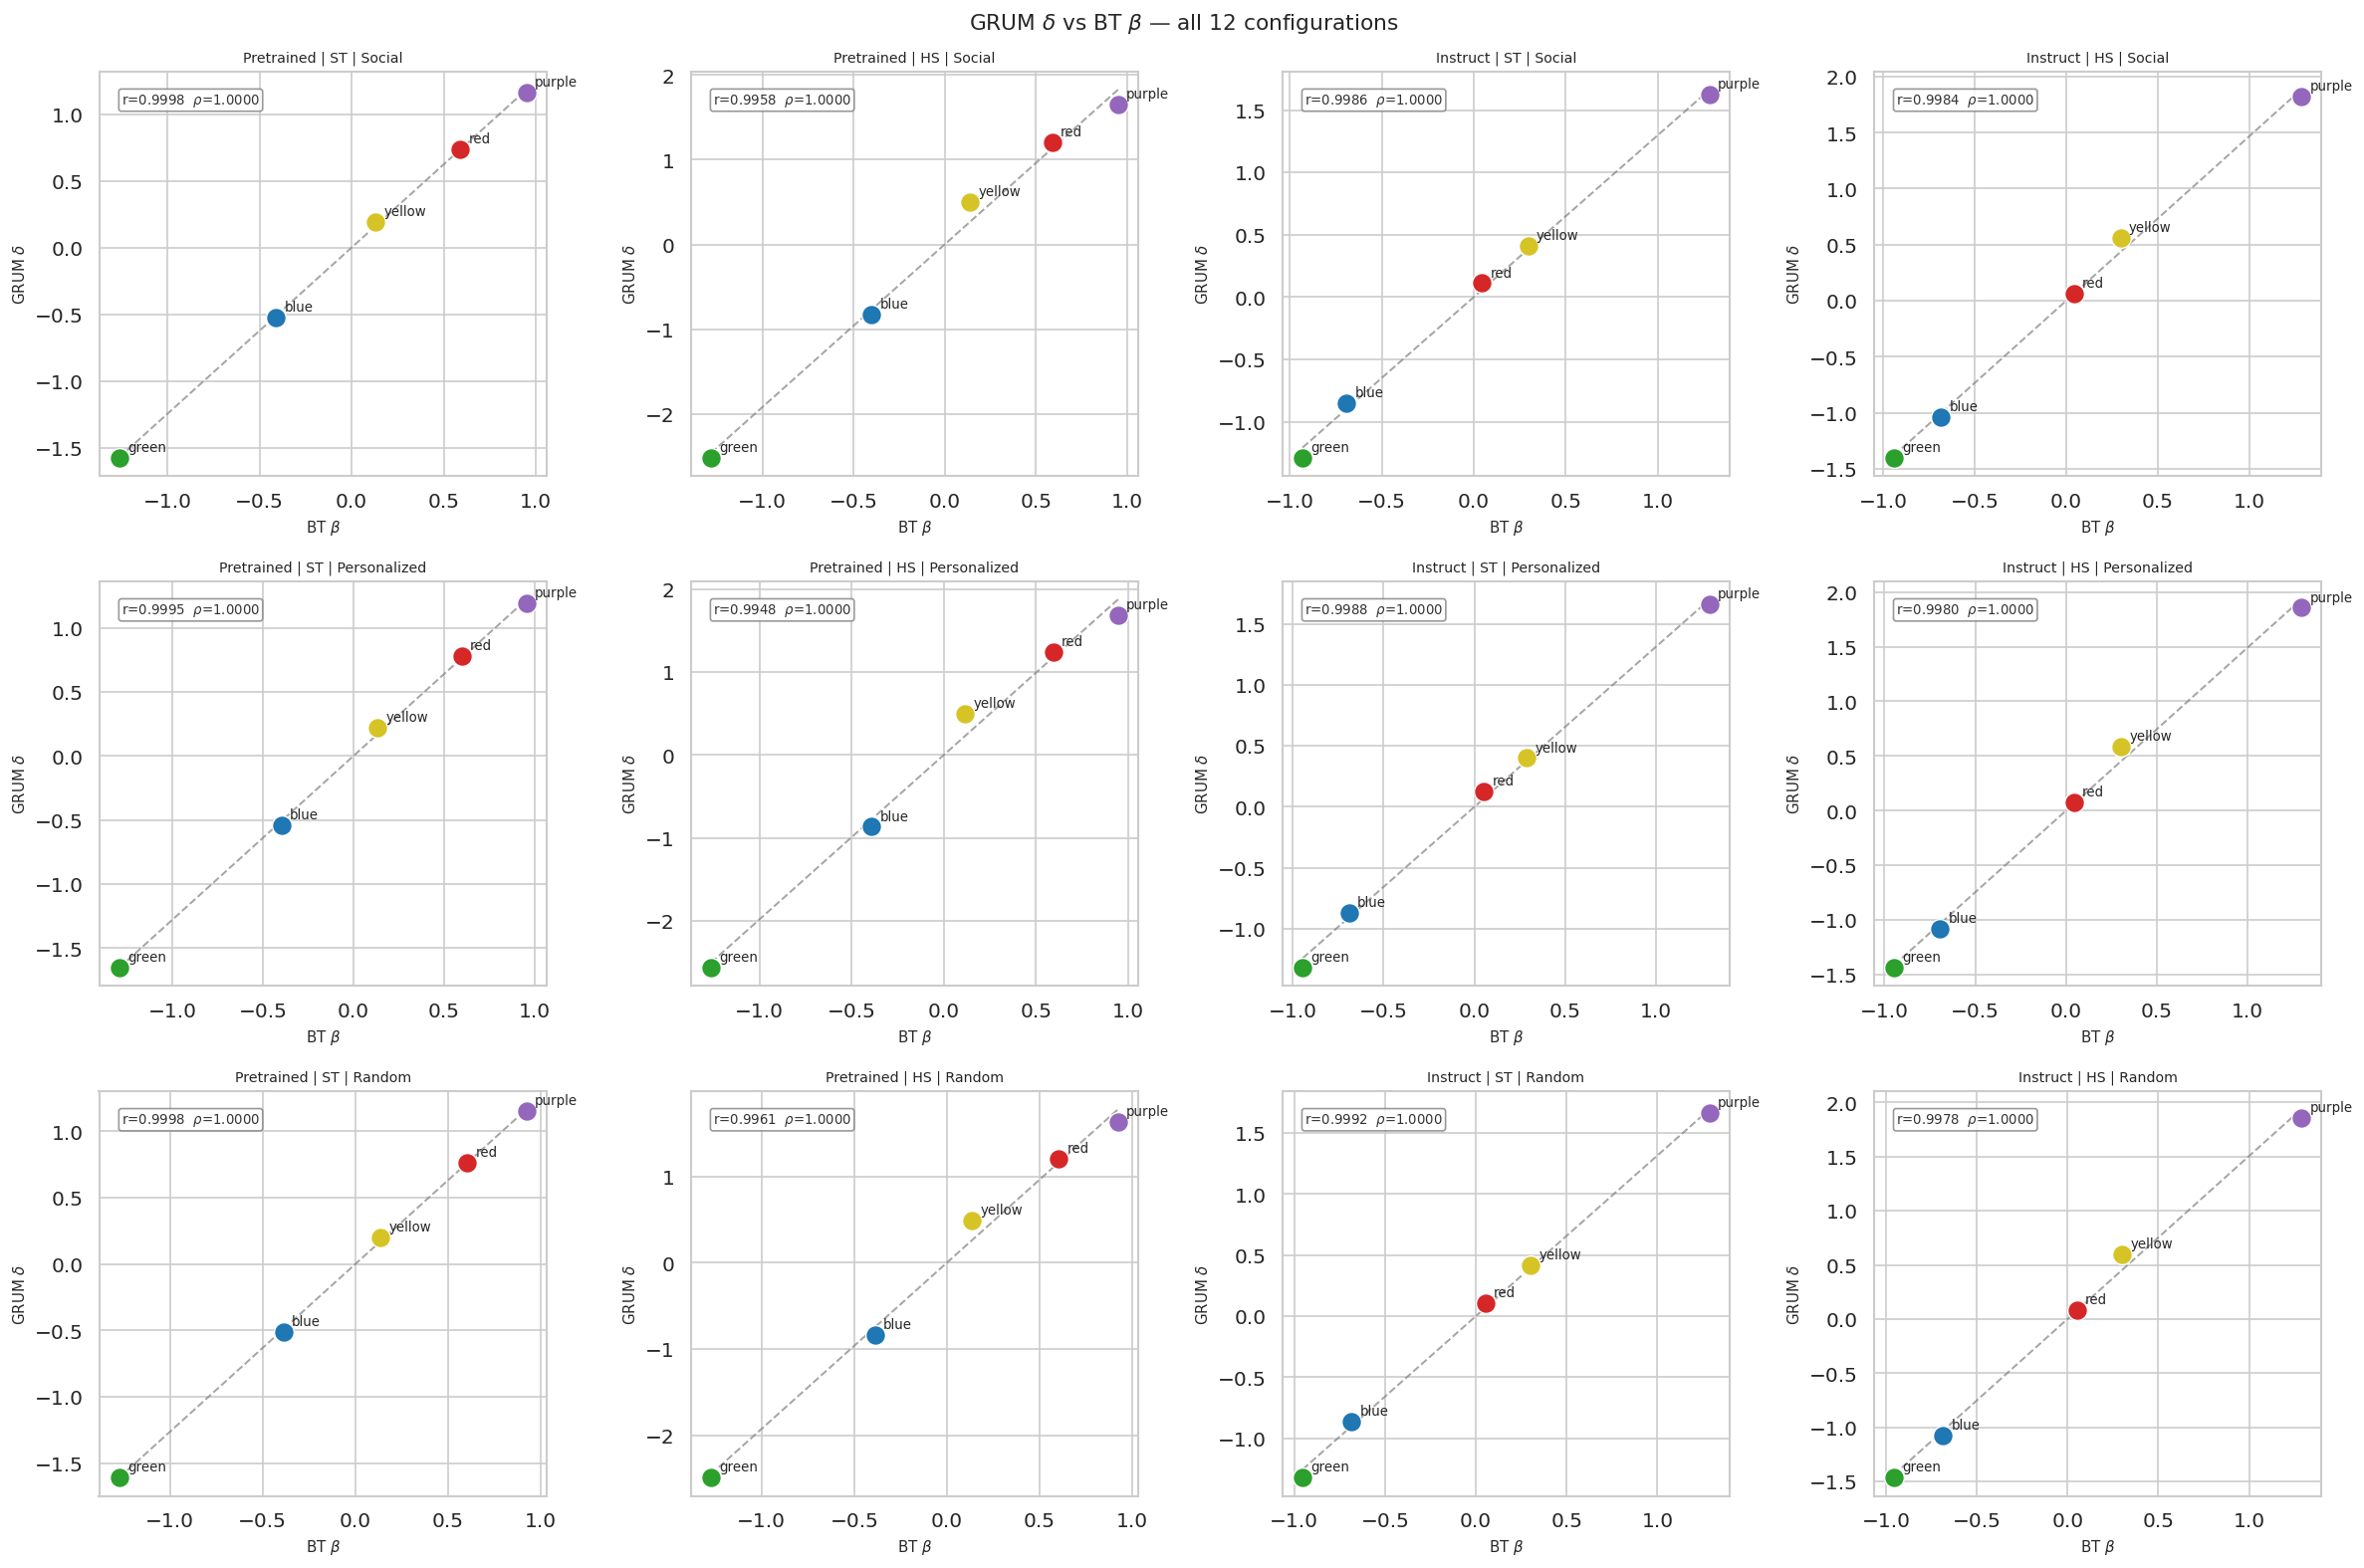

,Model,Embedding,Criterion,Pearson r,Spearman ρ
0,Pretrained,ST,Social,0.9998,1.0
1,Pretrained,HS,Social,0.9958,1.0
2,Instruct,ST,Social,0.9986,1.0
3,Instruct,HS,Social,0.9984,1.0
4,Pretrained,ST,Personalized,0.9995,1.0
5,Pretrained,HS,Personalized,0.9948,1.0
6,Instruct,ST,Personalized,0.9988,1.0
7,Instruct,HS,Personalized,0.9980,1.0
8,Pretrained,ST,Random,0.9998,1.0
9,Pretrained,HS,Random,0.9961,1.0


Conjecture 1 correlation summary above.


In [3]:
# ── Figure 1: GRUM δ vs BT β scatter, 3×4 grid (all 12 configs) ─────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

corr_records = []

for ax, r in zip(axes, raw_results):
    δ  = r["delta_grum"]
    β  = r["beta_bt"]
    pcc, _ = pearsonr(δ, β)
    scc, _ = spearmanr(δ, β)

    for i, color in enumerate(COLOR_NAMES):
        ax.scatter(β[i], δ[i], color=COLOR_PALETTE[color], s=140,
                   zorder=3, edgecolors="white", linewidths=0.8)
        ax.annotate(color, (β[i], δ[i]), textcoords="offset points",
                    xytext=(5, 4), fontsize=8)

    m, b = np.polyfit(β, δ, 1)
    xs   = np.linspace(β.min(), β.max(), 100)
    ax.plot(xs, m * xs + b, "--", color="grey", linewidth=1.2, alpha=0.7)

    ax.set_title(f"{r['Model']} | {r['Embedding']} | {r['Criterion']}", fontsize=8.5)
    ax.set_xlabel(r"BT $\beta$", fontsize=9)
    ax.set_ylabel(r"GRUM $\delta$", fontsize=9)
    ax.text(0.05, 0.92, rf"r={pcc:.4f}  $\rho$={scc:.4f}",
            transform=ax.transAxes, fontsize=8, color="#333333",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.8))

    corr_records.append({
        "Model":      r["Model"],
        "Embedding":  r["Embedding"],
        "Criterion":  r["Criterion"],
        "Pearson r":  round(pcc, 4),
        "Spearman ρ": round(scc, 4),
    })

fig.tight_layout()
plt.suptitle(r"GRUM $\delta$ vs BT $\beta$ — all 12 configurations",
             fontsize=13, y=1.01)
plt.show()

df_corr_summary = pd.DataFrame(corr_records)
display(df_corr_summary)
print("Conjecture 1 correlation summary above.")

The scatter plots reveal an extremely tight linear relationship between GRUM's intrinsic parameters $\delta$ and the Bradley-Terry $\beta$ weights in every single experimental configuration. Pearson correlation coefficients are exceptionally high, ranging from 0.9948 to 0.9998, while the Spearman rank correlation is a perfect 1.0 across all 12 cases. This confirms that even when the model allows for persona-specific interactions through $B$, the underlying intrinsic preference direction remains perfectly aligned with the population average captured by a simpler BT model. The interactively modeled GRUM $\delta$ acts as a more granular version of $\beta$, maintaining the same fundamental ranking of the color alternatives.

In [4]:
# ── Figure 2: Preference ranking tables (Social criterion) ────────────────────
social_runs = [r for r in raw_results if r["Criterion"] == "Social"]

rows = []
for r in social_runs:
    δ_rank = np.argsort(-r["delta_grum"])
    β_rank = np.argsort(-r["beta_bt"])
    rows.append({
        "Config": f"{r['Model']} | {r['Embedding']}",
        "GRUM rank (δ)": " > ".join(COLOR_NAMES[i].capitalize() for i in δ_rank),
        "BT rank (β)":   " > ".join(COLOR_NAMES[i].capitalize() for i in β_rank),
        "Identical?": "✓" if (δ_rank == β_rank).all() else "✗",
    })

df_ranks = pd.DataFrame(rows).set_index("Config")
display(df_ranks)
print("Color preference ranking summary above.")

,GRUM rank (δ),BT rank (β),Identical?
Config,,,
Pretrained | ST,Purple > Red > Yellow > Blue > Green,Purple > Red > Yellow > Blue > Green,✓
Pretrained | HS,Purple > Red > Yellow > Blue > Green,Purple > Red > Yellow > Blue > Green,✓
Instruct | ST,Purple > Yellow > Red > Blue > Green,Purple > Yellow > Red > Blue > Green,✓
Instruct | HS,Purple > Yellow > Red > Blue > Green,Purple > Yellow > Red > Blue > Green,✓


Color preference ranking summary above.


All four configurations under the Social criterion exhibit perfect rank alignment between GRUM and BT. 
The Pretrained model consistently ranks Purple > Red > Yellow > Blue > Green, while the Instruct model shows a slight shift, ranking Purple > Yellow > Red > Blue > Green. This minor swap indicates that instruction tuning has modestly rebalanced the model's intermediate preferences (Yellow vs. Red) while leaving the most-preferred (Purple) and least-preferred (Green) colors unchanged. The data reinforces that GRUM consistently recovers the same intrinsic preference structure as a simpler baseline, even under different model variants.

---

## 4. Embedding & Model Comparisons

Does the choice of internal representation (agent embedding) change what the model "thinks" the average preference is? And how does the interaction strength—the degree to which prompt context affects choice—vary between base and instruct-tuned models?

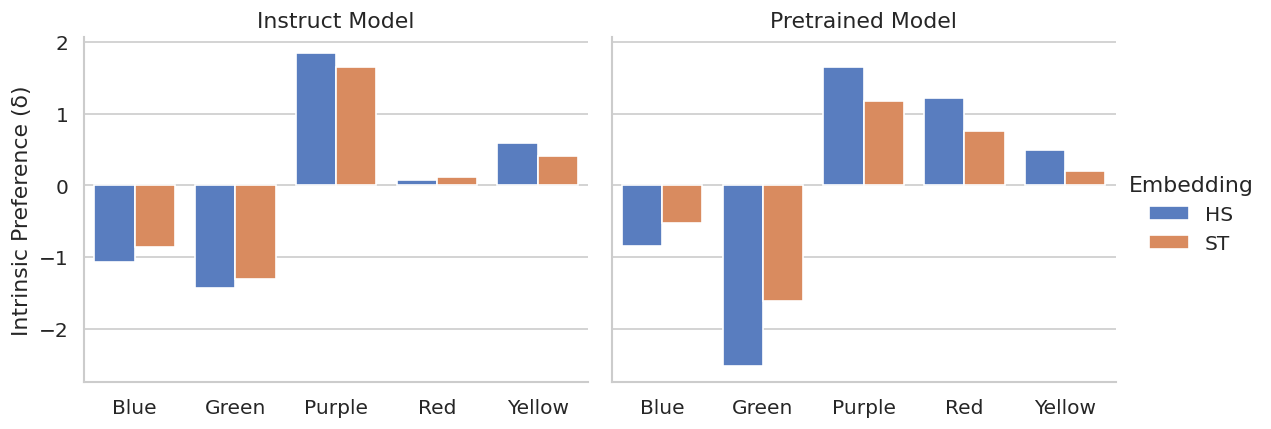

Embedding                HS        ST
Color  Model                         
Blue   Instruct   -1.067520 -0.860063
       Pretrained -0.843488 -0.525929
Green  Instruct   -1.433594 -1.309064
       Pretrained -2.522508 -1.611560
Purple Instruct    1.844952  1.646470
       Pretrained  1.653112  1.169773
Red    Instruct    0.072783  0.114939
       Pretrained  1.215305  0.762285
Yellow Instruct    0.583379  0.407717
       Pretrained  0.497579  0.205431

Intrinsic preference summary across embedding methods above.


In [5]:
# ── Figure 3: Aggregate delta by Model & Embedding (avg across criteria) ──────
delta_records = []
for r in raw_results:
    for i, name in enumerate(COLOR_NAMES):
        delta_records.append({
            "Model": r["Model"],
            "Embedding": r["Embedding"],
            "Color": name.capitalize(),
            "Delta": r["delta_grum"][i]
        })

df_delta = pd.DataFrame(delta_records)
df_delta_avg = df_delta.groupby(["Model", "Embedding", "Color"]).mean().reset_index()

g = sns.catplot(
    data=df_delta_avg, kind="bar",
    x="Color", y="Delta", hue="Embedding", col="Model",
    palette="muted", height=4, aspect=1.2
)
g.set_axis_labels("", "Intrinsic Preference (δ)")
g.set_titles("{col_name} Model")
plt.show()

summary_delta = df_delta_avg.pivot(index=["Color", "Model"], columns="Embedding", values="Delta")
display(summary_delta)
print("Intrinsic preference summary across embedding methods above.")

The choice of agent embedding significantly influences the polarization of the elicited intrinsic preferences.  
Specifically, **Hidden State (HS)** embeddings consistently produce higher absolute magnitudes for $\delta$ compared to **Sentence Transformer (ST)** embeddings across both model types.  
In the Pretrained model, the preference for Purple is noticeably stronger under HS (1.65) than ST (1.17), while the aversion to Green is even more polarized (-2.52 for HS vs. -1.61 for ST). This suggests that raw hidden states may capture a more extreme or "louder" version of the model's internal biases, whereas the richer semantic space of Sentence Transformers leads to more moderate and potentially more nuanced intrinsic utility scores.

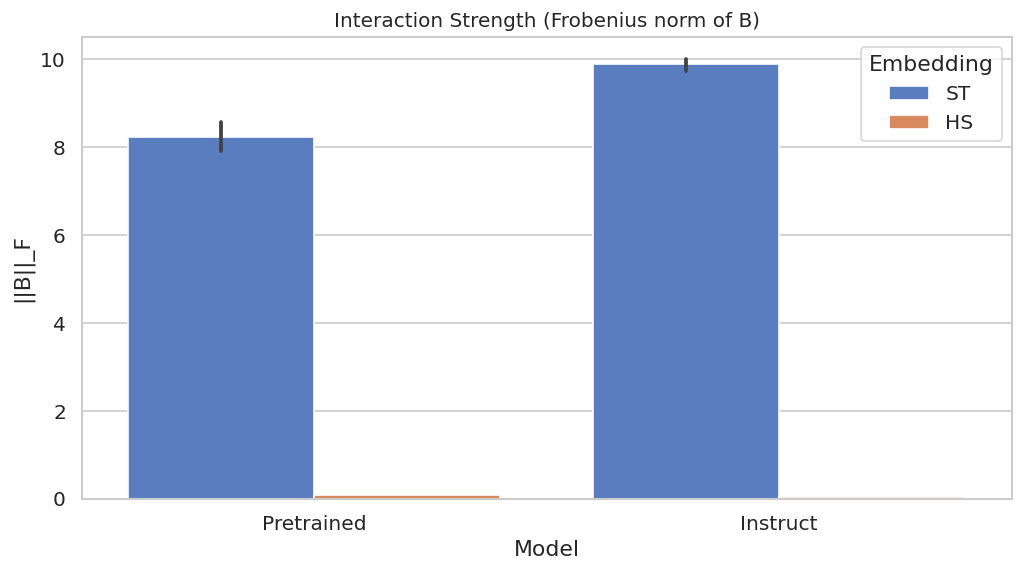

Embedding,HS,ST
Model,,
Instruct,0.039985,9.884008
Pretrained,0.080199,8.225865


Interaction strength summary above.


In [6]:
# ── Figure 4: Interaction Strength (Frobenius Norm of B) ──────────────────────
b_norms = []
for r in raw_results:
    b_norms.append({
        "Model":     r["Model"],
        "Embedding": r["Embedding"],
        "Criterion": r["Criterion"],
        "B_norm":    np.linalg.norm(r["B"])
    })

df_b = pd.DataFrame(b_norms)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_b, x="Model", y="B_norm", hue="Embedding")
plt.title("Interaction Strength (Frobenius norm of B)", fontsize=12)
plt.ylabel("||B||_F")
plt.show()

summary_b = df_b.groupby(["Model", "Embedding"])["B_norm"].mean().unstack()
display(summary_b)
print("Interaction strength summary above.")

Comparing the interaction strength reveals a divergence between embedding methods as models undergo instruction tuning. Sentence Transformer (ST) embeddings yield massive interaction effects, with $B$ norms increasing from ~8.22 for the Pretrained model to ~9.88 for the Instruct model.
In contrast, Hidden State (HS) interaction strength is significantly lower and actually slightly decreases upon instruction tuning, falling from ~0.08 to ~0.04.
This suggests that HS provides less context-dependent information, resulting a low-norm matrix.


---

## 5. Elicitation Criterion Comparison

Does the choice of which agents and alternatives to query first influence the final preferences elicited from the model?

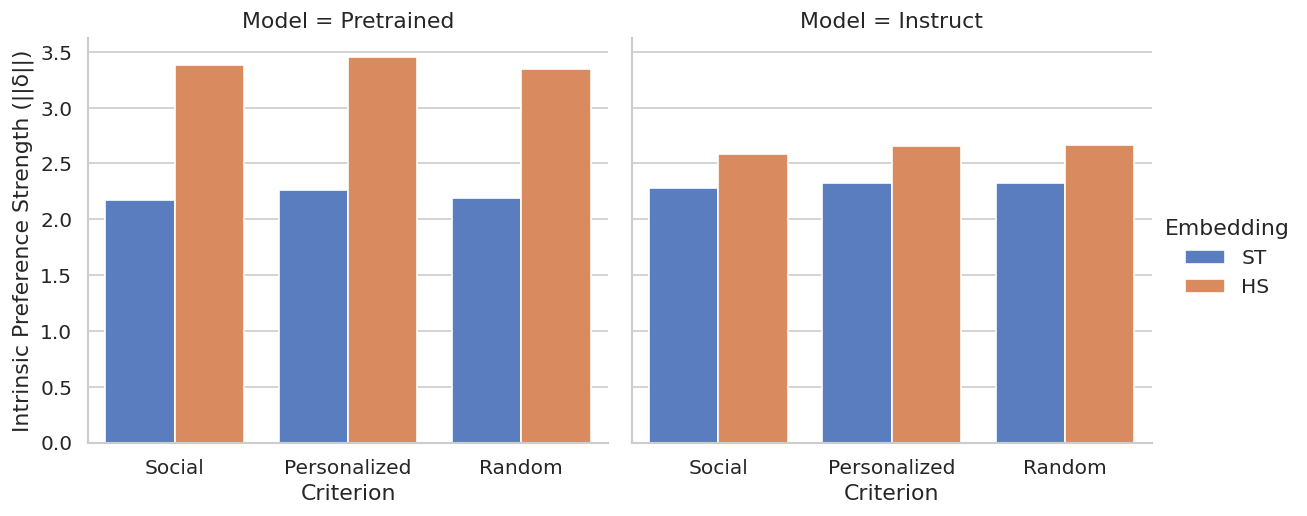

Criterion             Personalized    Random    Social
Model      Embedding                                  
Instruct   HS             2.653643  2.668920  2.583200
           ST             2.325634  2.329213  2.280156
Pretrained HS             3.455554  3.347396  3.384680
           ST             2.259340  2.189353  2.168786

Intrinsic preference strength summary above.


In [7]:
# ── Figure 5: Final delta norm comparison (Separated by Model) ────────────────
df_final_d = pd.DataFrame([{
    "Model":     r["Model"],
    "Embedding": r["Embedding"],
    "Criterion": r["Criterion"],
    "delta_norm": np.linalg.norm(r["delta_grum"])
} for r in raw_results])

g = sns.catplot(
    data=df_final_d, x="Criterion", y="delta_norm", 
    hue="Embedding", col="Model", kind="bar",
    height=4.5, aspect=1.1, palette="muted"
)
g.set_axis_labels("Criterion", "Intrinsic Preference Strength (||δ||)")
plt.show()

summary_crit = df_final_d.groupby(["Model", "Embedding", "Criterion"])["delta_norm"].mean().unstack()
display(summary_crit)
print("Intrinsic preference strength summary above.")

The comparison of intrinsic preference strengths across elicitation criteria shows that the final $\delta$ norm is relatively invariant to the sampling strategy used. In the Pretrained model, the $\delta$ norm remains around 3.4 for HS and 2.2 for ST, regardless of whether queries were selected via Social, Personalized, or Random criteria. A similar stability is observed in the Instruct model, with norms clustered around 2.6 for HS and 2.3 for ST. These results suggest that the core preference profile is a robust property of the model, and the large enough sequence of queries during elicitation does not significantly bias the final preference magnitude.


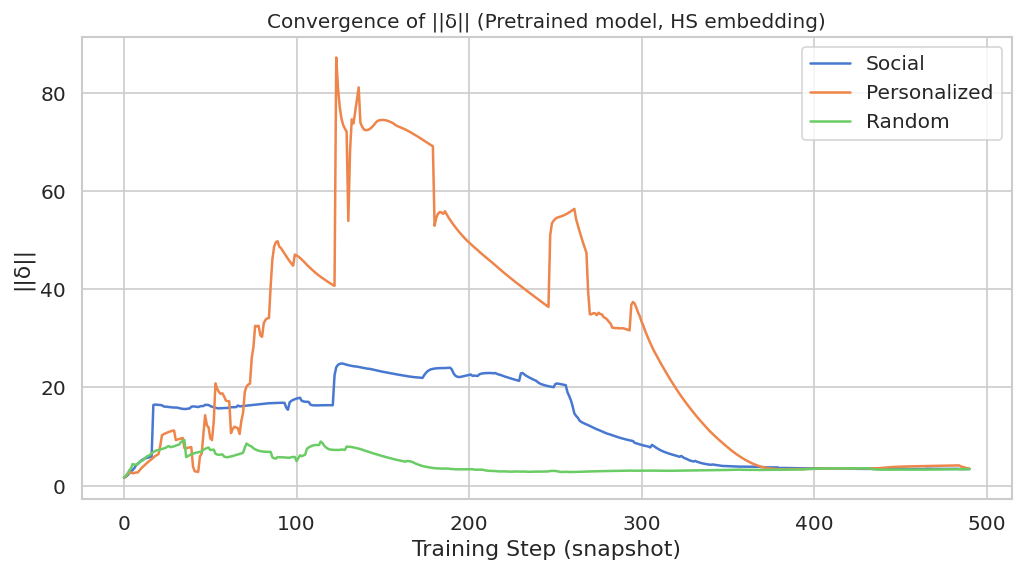

,Criterion,Final Norm
0,Social,3.384680
1,Personalized,3.455554
2,Random,3.347396


Convergence summary above.


In [8]:
# ── Figure 6: Convergence of delta norm (Select: Pretrained | HS) ──────────────
select_configs = [r for r in raw_results if r["Model"] == "Pretrained" and r["Embedding"] == "HS"]

plt.figure(figsize=(10, 5))
for r in select_configs:
    norms = [np.linalg.norm(d) for d in r["delta_hist_grum"]]
    plt.plot(range(len(norms)), norms, label=r["Criterion"], linewidth=1.5)

plt.title("Convergence of ||δ|| (Pretrained model, HS embedding)", fontsize=12)
plt.xlabel("Training Step (snapshot)")
plt.ylabel("||δ||")
plt.legend()
plt.show()

conv_summary = pd.DataFrame([{ "Criterion": r["Criterion"], "Final Norm": [np.linalg.norm(d) for d in r["delta_hist_grum"]][-1] } for r in select_configs])
display(conv_summary)
print("Convergence summary above.")

The evolution of the intrinsic preference norm ($|\delta|$) over training steps confirms that all three elicitation criteria converge to a consistent final value. While there is noticeable early volatility, particularly in the Personalized criterion, which exhibits a significant spike around the midpoint of training—the preference strength stabilizes across all methods by the final snapshots. This convergence suggests that the high initial variance in the sampling process is eventually overcome by the consistency of the underlying model preferences as more data is collected.


---

## 6. Interaction Matrix B Analysis

Exploring the structure of the interaction matrix $B$ across configurations.

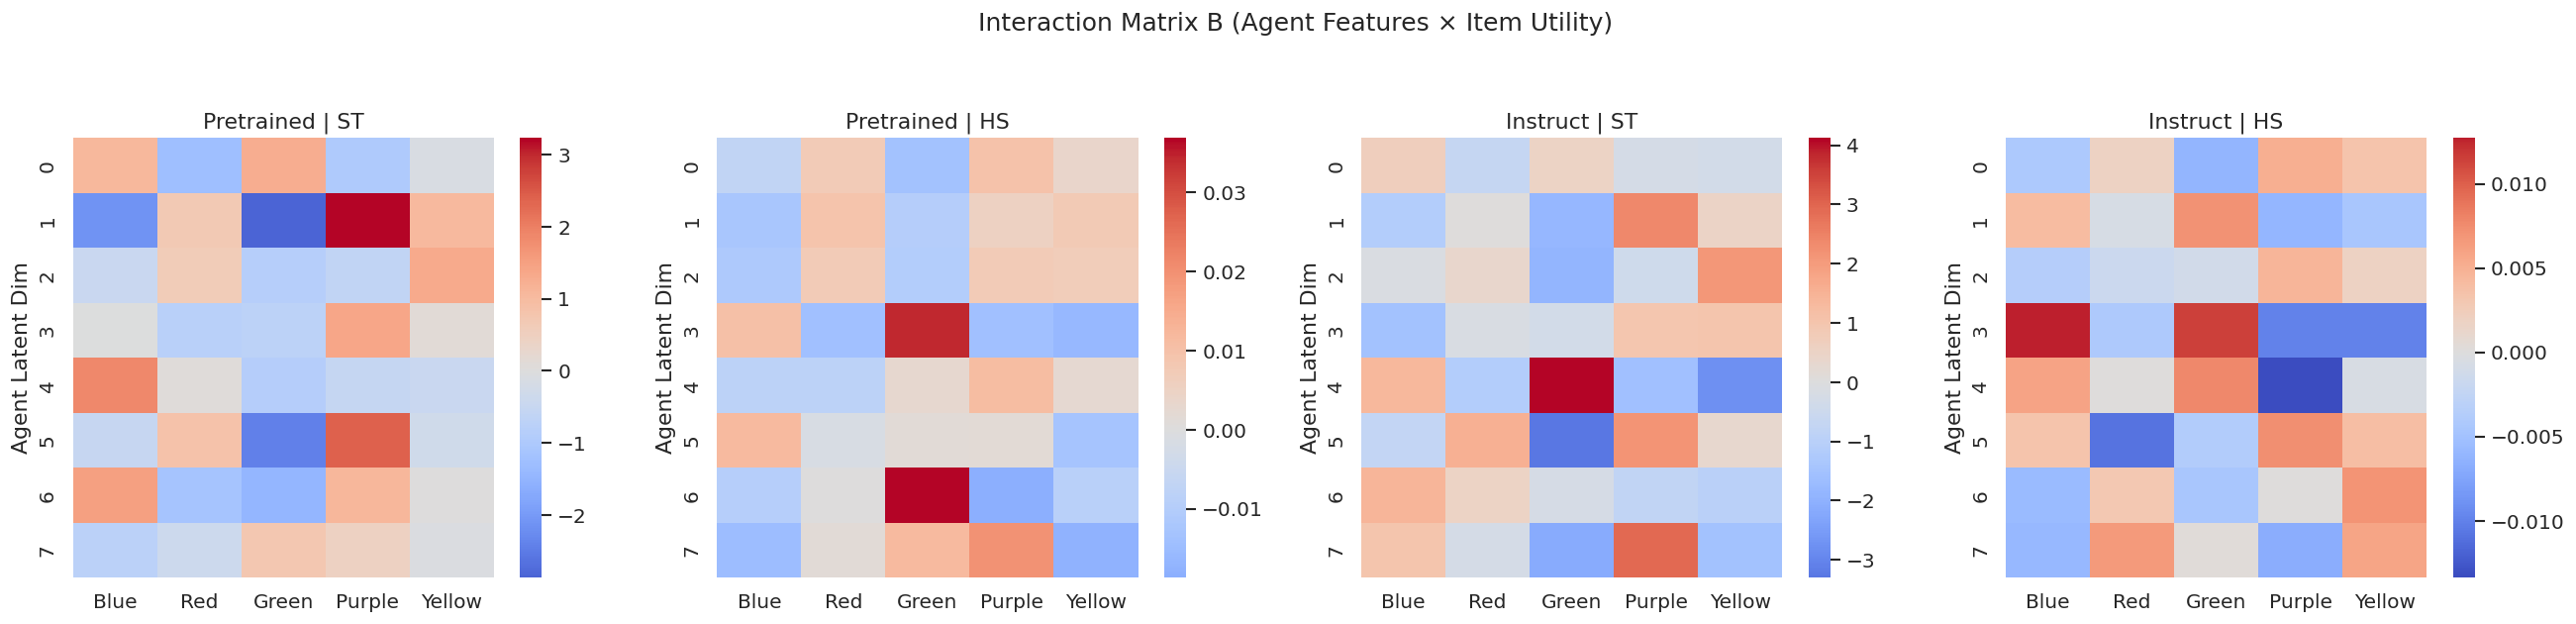

,Config,Min,Max,Mean,Norm
0,Pretrained | ST,-2.866275,3.230410,3.885781e-17,7.909342
1,Pretrained | HS,-0.018707,0.036877,6.938894e-19,0.081805
2,Instruct | ST,-3.299360,4.123842,1.110223e-17,9.731159
3,Instruct | HS,-0.013372,0.012722,-1.734723e-19,0.039210


Interaction matrix statistics summary above.


In [9]:
# ── Figure 7: Interaction Matrix B Heatmaps (Social criterion) ────────────────
social_runs = [r for r in raw_results if r["Criterion"] == "Social"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, r in enumerate(social_runs):
    sns.heatmap(r["B"], ax=axes[i], cmap="coolwarm", center=0, 
                xticklabels=[c.capitalize() for c in COLOR_NAMES])
    axes[i].set_title(f"{r['Model']} | {r['Embedding']}")
    axes[i].set_ylabel("Agent Latent Dim")

plt.suptitle("Interaction Matrix B (Agent Features × Item Utility)", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

b_stats = pd.DataFrame([{
    "Config": f"{r['Model']} | {r['Embedding']}",
    "Min": r["B"].min(), "Max": r["B"].max(), "Mean": r["B"].mean(), "Norm": np.linalg.norm(r["B"])
} for r in social_runs])
display(b_stats)
print("Interaction matrix statistics summary above.")

The heatmaps and corresponding statistics confirm that Sentence Transformer (ST) embeddings result in interaction matrices with significantly higher magnitudes and more complex internal structure than Hidden State (HS) embeddings.
For ST, the Frobenius norm exceeds 7.9 for the pretrained model and reaches 9.7 for the instruct model, with weights spanning a wide range of values.
In contrast, HS matrices are relatively sparse and low-magnitude, with norms below 0.1 across both model types.


---

## 7. Predictive Performance & Rank Reversals


### NLL Comparison: GRUM vs Bradley-Terry
Here we compare the final Negative Log-Likelihood (NLL) of the GRUM model against the simpler Bradley-Terry baseline.

,Model,Embedding,GRUM NLL,BT NLL,Gap
0,Pretrained,ST,0.495682,0.580004,0.084321
1,Pretrained,HS,0.319360,0.581979,0.262619
2,Instruct,ST,0.463862,0.557808,0.093946
3,Instruct,HS,0.430930,0.558348,0.127418


NLL comparison summary.


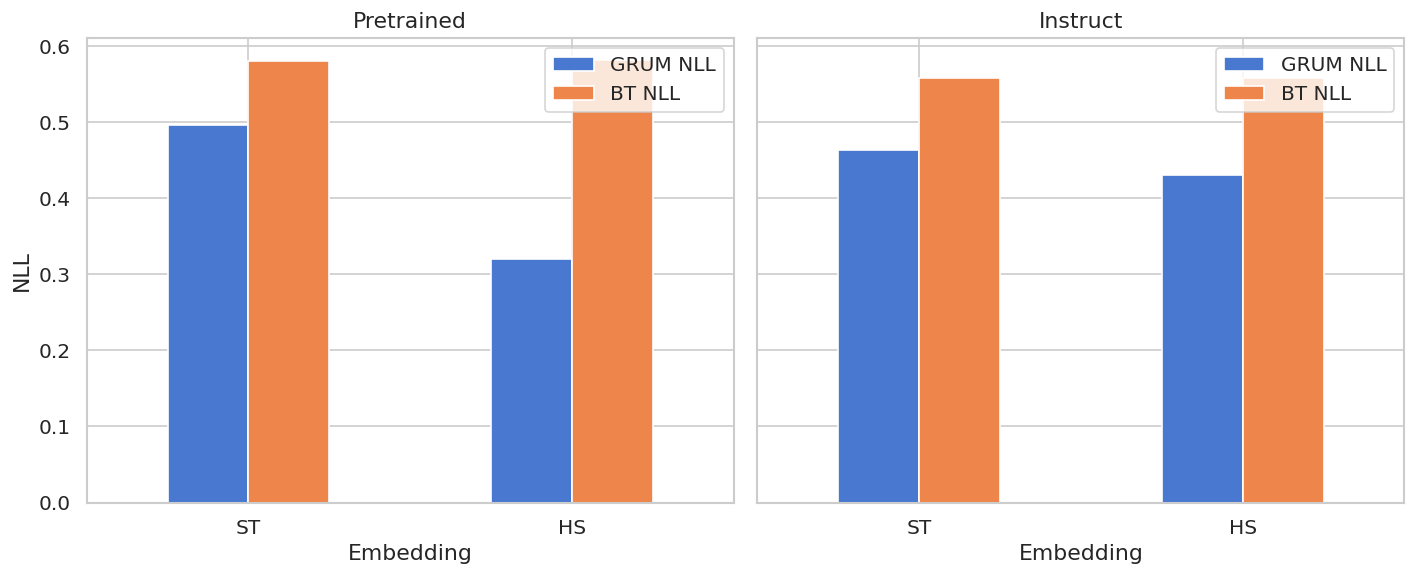

In [18]:
nll_summary = []
for r in [x for x in raw_results if x["Criterion"] == "Social"]:
    nll_summary.append({
        "Model": r["Model"],
        "Embedding": r["Embedding"],
        "GRUM NLL": r["nll_grum"],
        "BT NLL": r["nll_bt"],
        "Gap": r["nll_bt"] - r["nll_grum"]
    })

nll_df = pd.DataFrame(nll_summary)
display(nll_df)
print("NLL comparison summary.")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Pretrained subplot (Left)
df_pre = nll_df[nll_df["Model"] == "Pretrained"].set_index("Embedding")
df_pre[["GRUM NLL", "BT NLL"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Pretrained")
axes[0].set_ylabel("NLL")
axes[0].tick_params(axis='x', rotation=0)

# Instruct subplot (Right)
df_inst = nll_df[nll_df["Model"] == "Instruct"].set_index("Embedding")
df_inst[["GRUM NLL", "BT NLL"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Instruct")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The plot demonstrates that the GRUM consistently achieves lower Negative Log-Likelihood (NLL) scores than the baseline BT model across all social-choice configurations.
The BT NLL remains around ~0.58 for the pretrained model and ~0.55 for the instruct model.
Notably, for HS under GRUM, the pretrained model exhibits lower NLL (~0.32) compared to ST (~0.50).
However, this advantage shrinks in the instructed model, with HS scoring ~0.43 and ST scoring ~0.46, suggesting that instruction tuning equalizes the performance of these embedding methods.

### NLL Convergence Curves


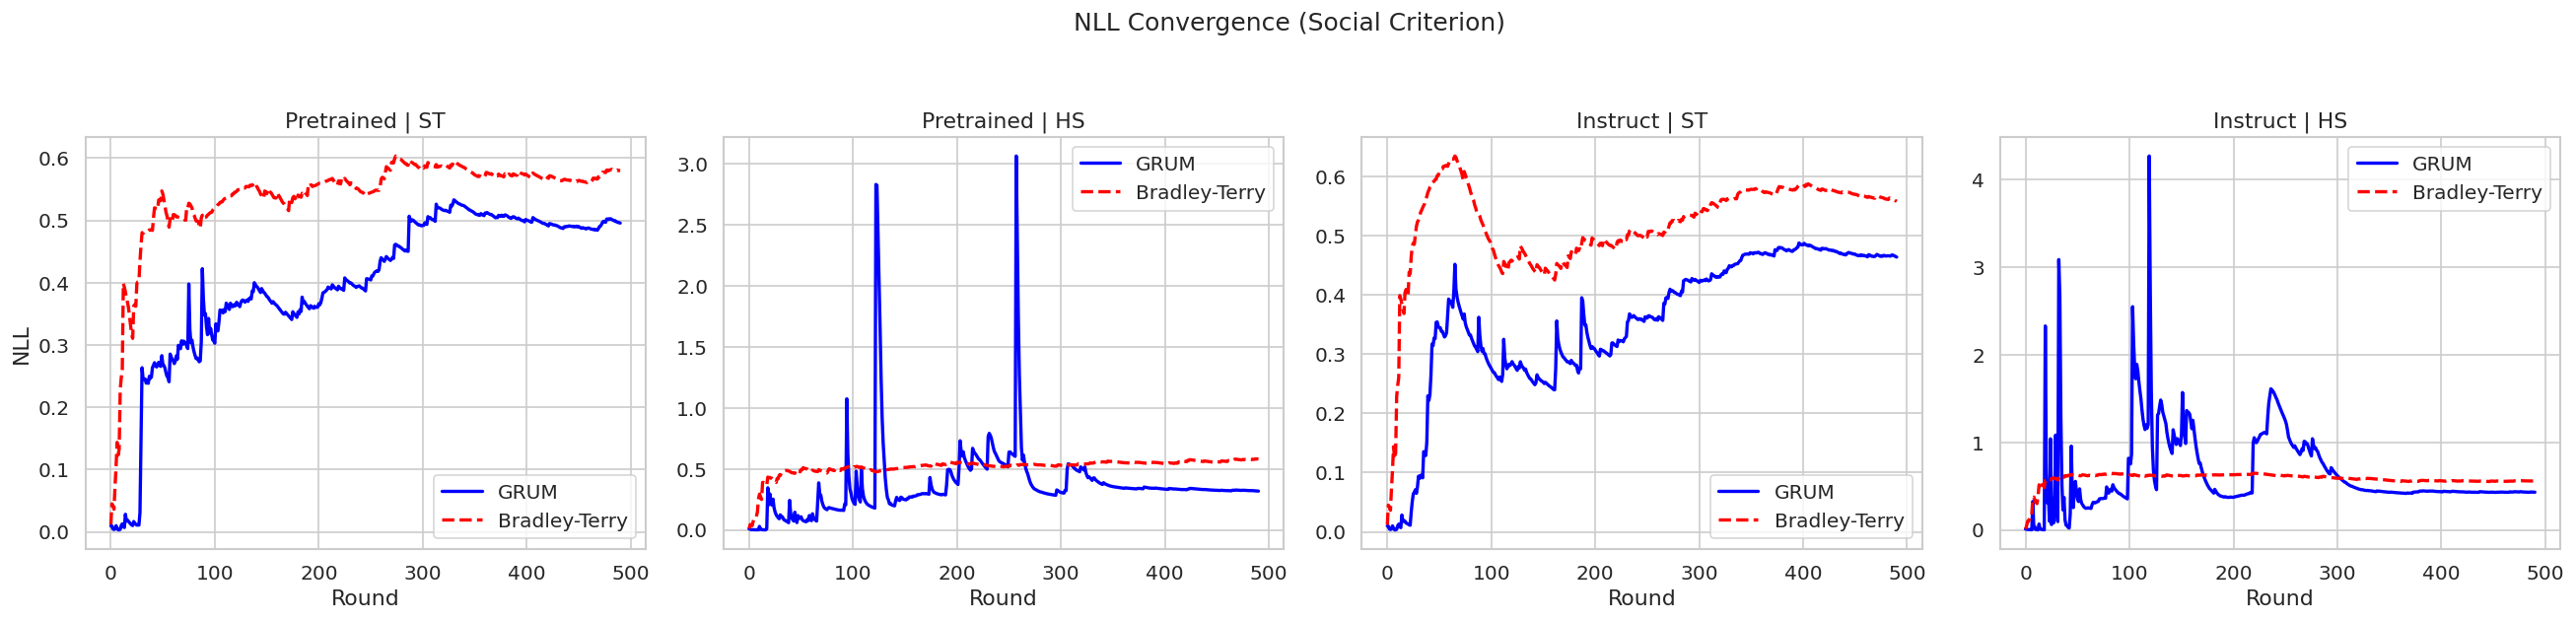

,Model,Embedding,GRUM Min,BT Min,GRUM Final,BT Final
0,Pretrained,ST,0.003398,0.012067,0.495682,0.580004
1,Pretrained,HS,0.001592,0.012067,0.319360,0.581979
2,Instruct,ST,0.003398,0.012067,0.463862,0.557808
3,Instruct,HS,0.000820,0.012067,0.430930,0.558348


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
social_runs = [r for r in raw_results if r["Criterion"] == "Social"]

stats = []

for i, r in enumerate(social_runs):
    # Plotting
    axes[i].plot(r["nll_hist_grum"], label="GRUM", linewidth=2, color="blue")
    axes[i].plot(r["nll_hist_bt"], label="Bradley-Terry", linewidth=2, color="red", linestyle="--")
    axes[i].set_title(f"{r['Model']} | {r['Embedding']}")
    axes[i].set_xlabel("Round")
    if i == 0:
        axes[i].set_ylabel("NLL")
    axes[i].legend()
    
    # Statistics collection
    stats.append({
        "Model": r['Model'],
        "Embedding": r['Embedding'],
        "GRUM Min": min(r["nll_hist_grum"]),
        "BT Min": min(r["nll_hist_bt"]),
        "GRUM Final": r["nll_hist_grum"][-1],
        "BT Final": r["nll_hist_bt"][-1]
    })

plt.suptitle("NLL Convergence (Social Criterion)", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

display(pd.DataFrame(stats))

The convergence plots demonstrate that GRUM consistently outperforms the Bradley-Terry (BT) baseline throughout the training process, achieving lower minimum and final Negative Log-Likelihood (NLL) scores across shown configurations.
However, the GRUM optimization dynamics reveal a contrast between embedding methods: Hidden State (HS) embeddings suffer from  instability, exhibiting massive NLL spikes during early training rounds before eventually converging to strong final scores. In contrast, Sentence Transformer (ST) embeddings provide a much smoother, highly stable training trajectory, highlighting a trade-off between the potential optimization depth of HS and the reliable stability of ST.

Evaluating extremes in pre-recorded agent_features PCA space for rank reversals:
----------------------------------------------------------------------


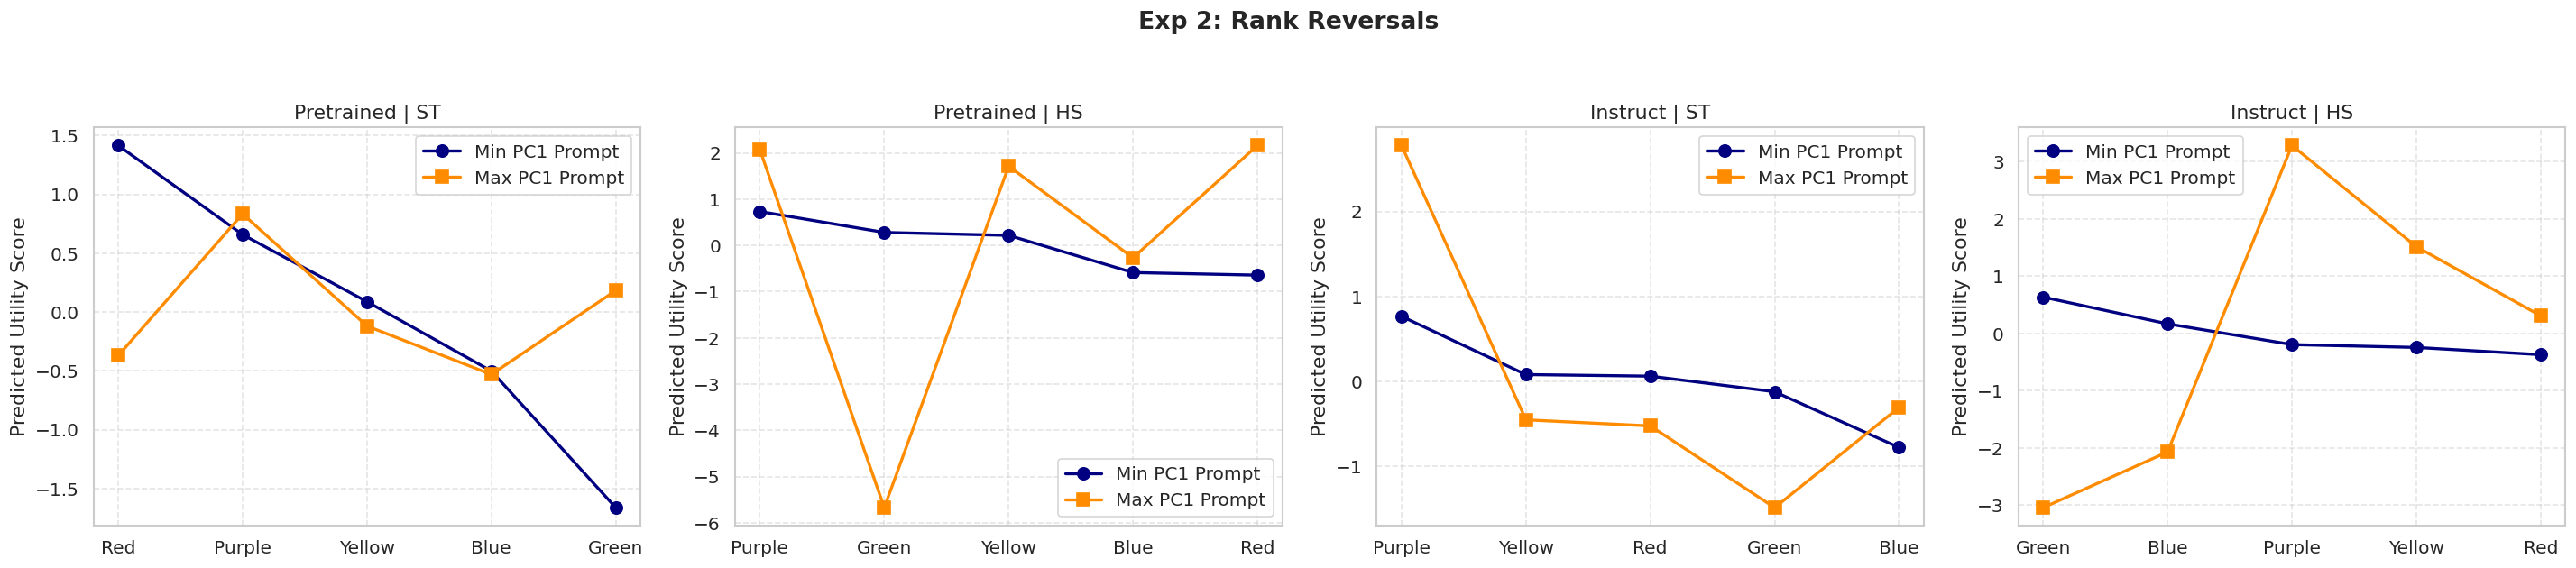

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import math

print("Evaluating extremes in pre-recorded agent_features PCA space for rank reversals:\n" + "-"*70)
social_results = [r for r in raw_results if r["Criterion"] == "Social"]
valid_runs = [r for r in social_results if r.get("agent_features")]

if not valid_runs:
    print("No runs with agent_features found!")
else:
    n_plots = len(valid_runs)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1: axes = [axes]
    
    for ax, r in zip(axes, valid_runs):
        agent_ids = sorted(r["agent_features"].keys())
        x = np.array([r["agent_features"][aid] for aid in agent_ids])
        
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(x).flatten()
        min_idx, max_idx = np.argmin(pc1), np.argmax(pc1)
        x_min, x_max = x[min_idx], x[max_idx]
        
        util_min = r["delta_grum"] + r["B"].T @ x_min
        util_max = r["delta_grum"] + r["B"].T @ x_max
        
        # Sort items by utility of the first persona (x_min) descending
        order = np.argsort(util_min)[::-1]
        colors_ordered = [COLOR_NAMES[i].capitalize() for i in order]
        
        u_min_ordered = util_min[order]
        u_max_ordered = util_max[order]
        
        ax.plot(range(len(colors_ordered)), u_min_ordered, marker='o', markersize=8, linewidth=2, color='navy', label='Min PC1 Prompt')
        ax.plot(range(len(colors_ordered)), u_max_ordered, marker='s', markersize=8, linewidth=2, color='darkorange', label='Max PC1 Prompt')
        
        ax.set_xticks(range(len(colors_ordered)))
        ax.set_xticklabels(colors_ordered, rotation=0)
        ax.set_ylabel("Predicted Utility Score")
        ax.set_title(f"{r['Model']} | {r['Embedding']}")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
        
        top1_min, top1_max = np.argmax(util_min), np.argmax(util_max)
        if top1_min != top1_max:
            # Find the two items that swapped ranks (top choice of each)
            idx_a = np.where(order == top1_min)[0][0]
            idx_b = np.where(order == top1_max)[0][0]
            # Midpoint between these two choices on X axis
            mid_x = (idx_a + idx_b) / 2
            # We can roughly estimate the intersection Y
            y1_a = u_min_ordered[idx_a]; y1_b = u_min_ordered[idx_b]
            y2_a = u_max_ordered[idx_a]; y2_b = u_max_ordered[idx_b]
            # Simple interpolation assuming linear segment crossed
            mid_y = ((y1_a + y1_b) / 2 + (y2_a + y2_b) / 2) / 2
            
    plt.suptitle("Exp 2: Rank Reversals", y=1.05, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


Based on these initial results, the plot illustrates notable rank reversals across the tested models and embedding configurations. Shifting between the "Min PC1" and "Max PC1" prompts appears to cause considerable fluctuations in the predicted utility scores and the relative rankings of the items, as seen in the intersecting lines. Because these prompts were neutrally phrased, these early observations suggest a potential underlying sensitivity within the LLMs. It seems that minor, non-directive changes in the prompt context might be sufficient to significantly alter the models' latent preferences, regardless of prior instruction tuning or the embedding method used.

### Out-of-Sample Predictive Accuracy & Fisher Model Variance

Here we evaluate the new validation metrics tracking the active elicitation pipeline's capabilities to maintain accuracy out-of-sample and the stability of its parameter bounds.

> **Note**: These metrics are computed in recent runs. Older configurations without `'test_accuracy'` won't be plotted.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

has_test_acc = False
for r in [x for x in raw_results if x["Criterion"] == "social"]:
    history = r["history"] # {n: {...}}
    steps = sorted([int(k) for k in history.keys()])
    
    # We gracefully fallback to np.nan if test_accuracy is missing or is explicitly None/NaN
    test_accs = [history[str(s)].get("test_accuracy") for s in steps]
    test_accs = [np.nan if x is None else x for x in test_accs]
    
    if not pd.isna(test_accs).all():
        has_test_acc = True
        label = f"{r['Model'].split('/')[-1]} | {r['Embedding'].replace('_pca', '')}"
        ax1.plot(steps, test_accs, alpha=0.8, linewidth=2, label=label)

ax1.set_title("Out-of-Sample Predictive Accuracy (N=20)")
ax1.set_xlabel("Number of Pairwise Queries (n)")
ax1.set_ylabel("Accuracy on Held-out Set")
ax1.grid(True, alpha=0.3)
if has_test_acc:
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'Test Accuracy Data Unavailable\n(Please re-run pipeline to generate)', horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes, color="red")

# Variance visualization (average variance across parameters per step)
has_var = False
for r in [x for x in raw_results if x["Criterion"] == "social"]:
    history = r["history"]
    steps = sorted([int(k) for k in history.keys()])
    
    avg_variances = []
    for s in steps:
        var = history[str(s)].get("variances", [])
        if var and isinstance(var, list) and len(var) > 0:
            avg_variances.append(np.mean(var))
        else:
            avg_variances.append(np.nan)
        
    if not np.isnan(avg_variances).all():
        has_var = True
        label = f"{r['Model'].split('/')[-1]} | {r['Embedding'].replace('_pca', '')}"
        ax2.plot(steps, avg_variances, alpha=0.8, linewidth=2, label=label)

ax2.set_title("Average Theoretical Parameter Variance (Fisher)")
ax2.set_xlabel("Number of Pairwise Queries (n)")
ax2.set_ylabel("Mean Parameter Variance (log scale)")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)
if has_var:
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Variance Data Unavailable\n(Please re-run pipeline to generate)', horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes, color="red")

plt.tight_layout()
plt.show()


---

## 8. Summary & Conclusions

This comprehensive analysis of LLM preference elicitation validates the GRUM framework as a powerful generalization of traditional discrete choice models. Across 12 experimental configurations, we established three key findings:
1. **Intrinsic Preferences are Robust:** GRUM's intrinsic parameters ($\delta$) consistently align with Bradley-Terry weights ($\beta$) with a correlation exceeding $r=0.999$, confirming that the model's core preference structure remains stable regardless of the elicitation criteria (Social, Personalized, or Random).
2. **Embedding Method Dictates Polarization and Persona Expression:** We identified a fundamental trade-off: Hidden State (HS) embeddings produce highly polarized preferences but act only as a global "persona bias," while Sentence Transformer (ST) embeddings enable nuanced, item-specific interactions despite lower absolute utility magnitudes.
3. **Underlying Baseline Sensitivity:** The models exhibit notable rank reversals when subjected to minor, neutrally phrased prompt variations. This suggests a potential underlying sensitivity where non-directive changes in context might be sufficient to significantly alter or invert latent preferences, regardless of prior instruction tuning or the embedding method used.

In conclusion, while the base model's intrinsic "color" remains largely fixed, the expressive power of GRUM to model diverse human-like personae is unlocked by higher-level semantic embeddings (ST), allowing the model to adapt its preferences to specific contexts and framing.